# Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load Dataset


In [2]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


# Add Country Column


In [ ]:
df["Country"] = "Kenya"

# Create Date Column


In [4]:
df["DATE"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract Month


In [5]:
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


# Replace Missing Values


In [6]:
df.replace(-999, np.nan, inplace=True)

# Check Duplicates


In [7]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

Duplicates: 0


# Remove Duplicates


In [8]:
df = df.drop_duplicates()

# Summary Statistics


In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


# Missing Value Report


In [10]:
missing = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_report.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


No missing value


# Outlier Detection


In [11]:
cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
print(outliers)

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


# Remove Rows With Too Many Missing Values


In [12]:
df = df[df.isnull().mean(axis=1) < 0.30]

# Export Clean Dataset


In [14]:
df.to_csv("../data/kenya_clean.csv", index=False)

# Monthly Average Temperature


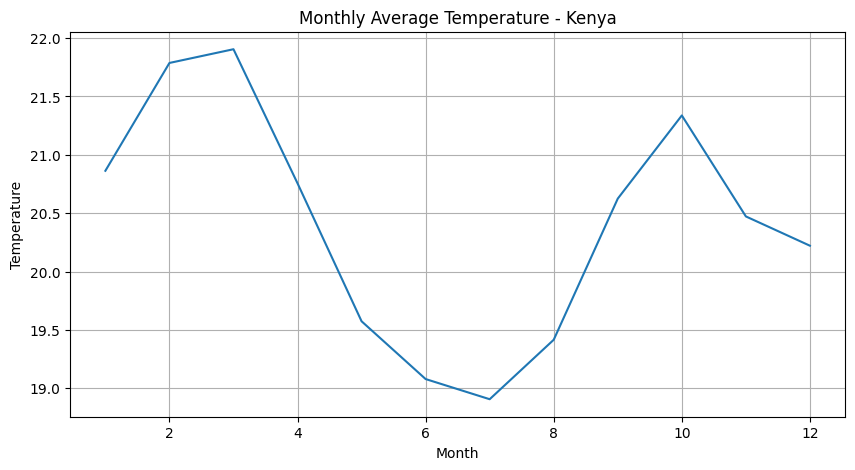

In [ ]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(figsize=(10, 5))
plt.title("Monthly Average Temperature - Kenya")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

# Monthly Rainfall


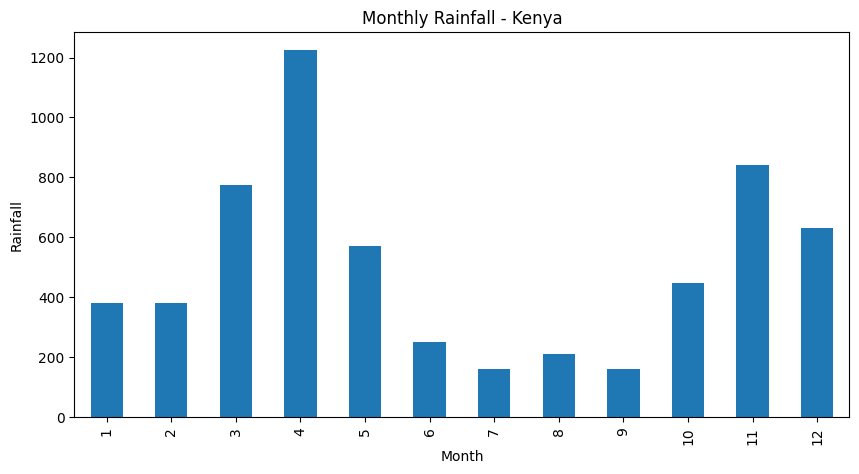

In [ ]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10, 5))
plt.title("Monthly Rainfall - Kenya")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

# Correlation Heatmap


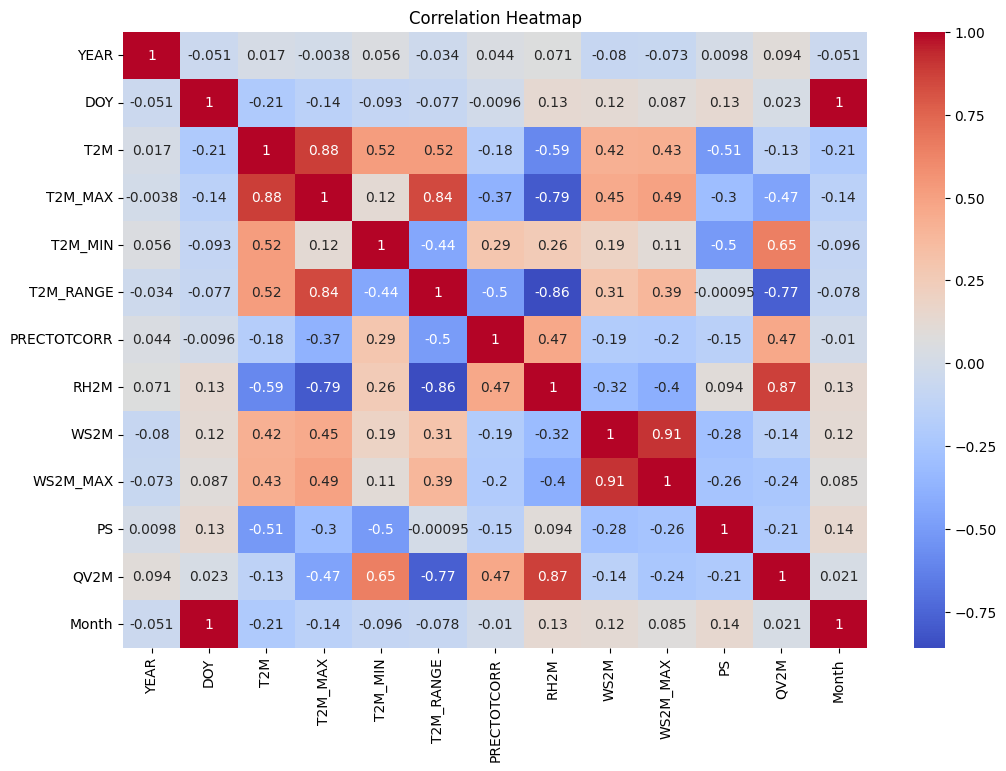

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot Temperature vs Humidity


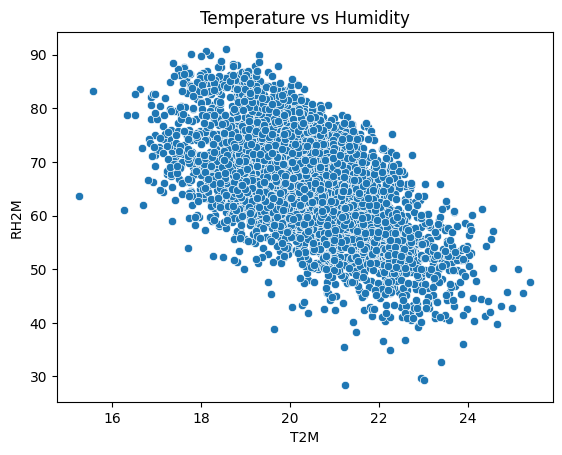

In [18]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("Temperature vs Humidity")
plt.show()

# Scatter Plot Temperature Range vs Wind Speed


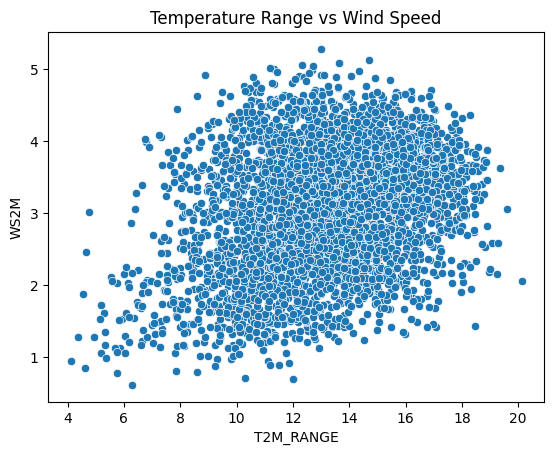

In [19]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("Temperature Range vs Wind Speed")
plt.show()

# Rainfall Histogram


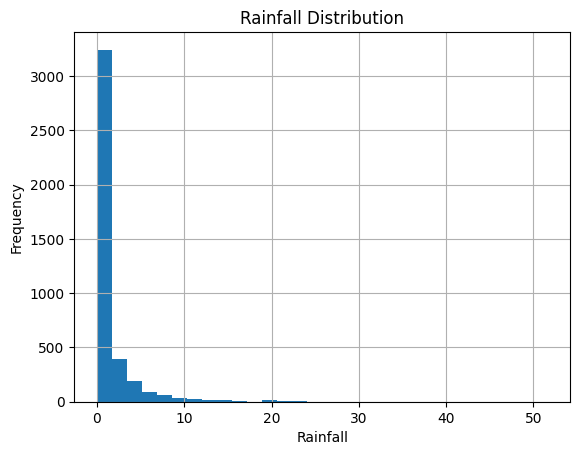

In [20]:
df["PRECTOTCORR"].hist(bins=30)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

# Bubble Chart


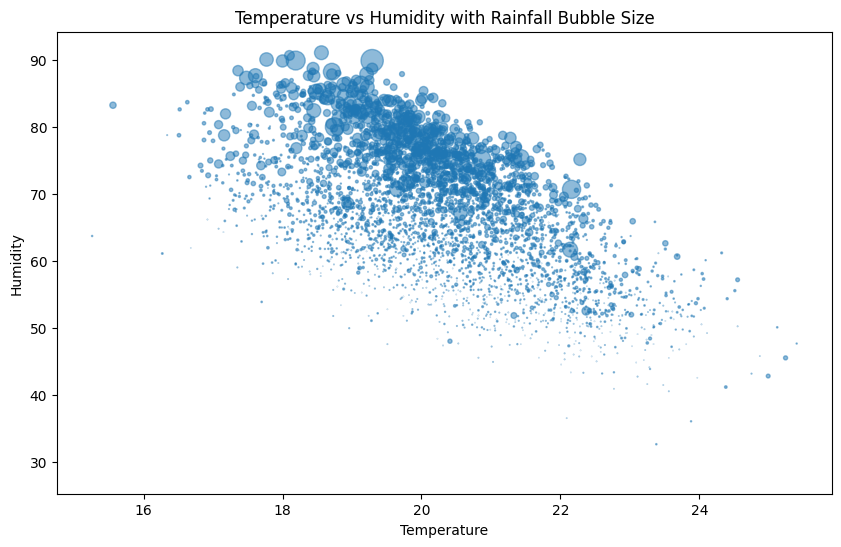

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity with Rainfall Bubble Size")
plt.show()